In [48]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
# import plotly.express as px
# import seaborn as sns
# import folium 

## 1.1) Subjects.csv 파일 읽어와서 df 변수에 저장하기

In [49]:
df = pd.read_csv('./data/Subjects.csv')
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


## 1.2) df DataFrame에 '총점'과 '평균' 열을 추가하여, 각 학생 별 총점, 평균 점수를 입력

In [50]:
## 나의 방법
df['총점'] = df.kor+df.eng+df.math+df.science
df['평균'] = (df.kor+df.eng+df.math+df.science)/4
df

## 이렇게도 가능하다 (내장 함수 사용하기!!!)
df['총점'] = df[['kor','eng','math','science']].sum(axis=1)
df['평균'] = df[['kor','eng','math','science']].mean(axis=1)
df

,class,name,kor,eng,math,science,총점,평균
0,1,aaa,67,87,90,98,342,85.50
1,1,bbb,45,45,56,98,244,61.00
2,1,ccc,95,59,96,88,338,84.50
3,1,ddd,65,94,89,98,346,86.50
4,1,eee,45,65,78,98,286,71.50
5,1,fff,78,76,98,89,341,85.25
6,2,ggg,87,67,65,56,275,68.75
7,2,hhh,89,98,78,78,343,85.75
8,2,iii,100,78,56,65,299,74.75
9,2,jjj,99,89,87,87,362,90.50


## 1.3) Class 1반과 Class 2반의 평균 점수를 각각 출력

In [51]:
class1avgs = df.loc[df['class']==1, '평균']
class2avgs = df.loc[df['class']==2, '평균']
class1avgs

0    85.50
1    61.00
2    84.50
3    86.50
4    71.50
5    85.25
Name: 평균, dtype: float64

In [52]:
class1avg = class1avgs.mean().round(2)
class2avg = class2avgs.mean().round(2)

In [53]:
print(f'Class 1반 평균: {class1avg}, Class 2반 평균: {class2avg}')

Class 1반 평균: 79.04, Class 2반 평균: 77.12


## 1.4) Class 1반과 Class 2반 두 집단의 차이가 유의한지 p value 값 계산하기
- p-value(유의확률)는 통계학에서 실험 결과가 단순한 '우연'일 확률을 나타내는 지표입니다. p-값이 작을수록 얻어낸 결과가 우연이 아니며, 유의미한 인과관계나 차이가 있다는 것을 의미합니다.

In [54]:
from scipy import stats

## p-value 계산
t_stat, p_value = stats.ttest_ind(class1avgs, class2avgs)
print(f't_stat: {t_stat.round(2)}, p_value: {p_value.round(2)}')

t_stat: 0.32, p_value: 0.76


## 1.5) Class 별 과목 분석
- 과목 별 패턴 분석: 국어를 잘하면 영어도 잘한다. 수학을 잘하면 과학도 잘한다.. 이런 패턴여부가 성립하는지 분석 => 시각화 하기.

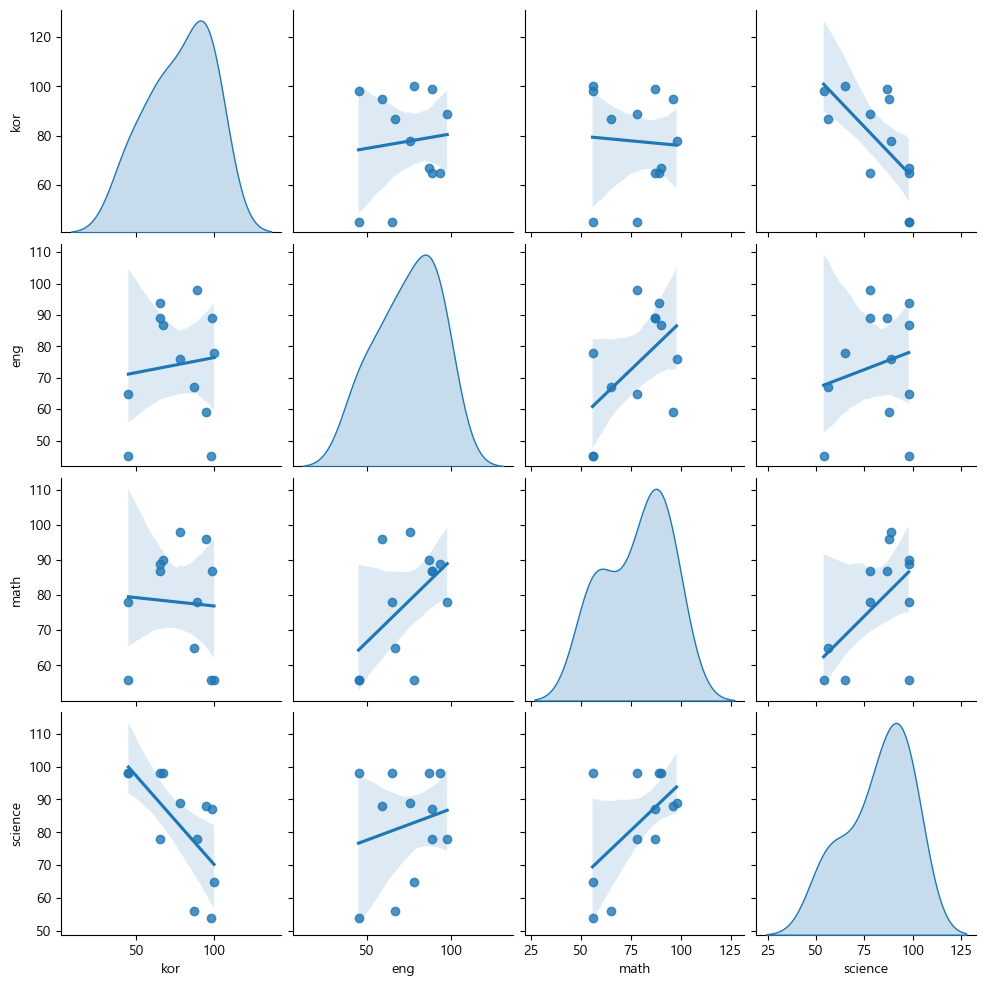

In [55]:
corr = df[['kor','eng','math','science']].corr()

sns.pairplot(df[['kor', 'eng', 'math', 'science']], 
             kind='reg',        # 추세선 포함
             diag_kind='kde')   # 대각선에 분포 표시
plt.show()